In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
orders = pd.read_csv("Orders.csv")
details = pd.read_csv("Details.csv")

In [4]:
print("Orders shape:",orders.shape)
print("Details shape:",details.shape)

Orders shape: (500, 5)
Details shape: (1500, 7)


In [5]:
orders.head()

,Order ID,Order Date,CustomerName,State,City
0,B-26055,10-03-2018,Harivansh,Uttar Pradesh,Mathura
1,B-25993,03-02-2018,Madhav,Delhi,Delhi
2,B-25973,24-01-2018,Madan Mohan,Uttar Pradesh,Mathura
3,B-25923,27-12-2018,Gopal,Maharashtra,Mumbai
4,B-25757,21-08-2018,Vishakha,Madhya Pradesh,Indore


In [6]:
details.head()

,Order ID,Amount,Profit,Quantity,Category,Sub-Category,PaymentMode
0,B-25681,1096,658,7,Electronics,Electronic Games,COD
1,B-26055,5729,64,14,Furniture,Chairs,EMI
2,B-25955,2927,146,8,Furniture,Bookcases,EMI
3,B-26093,2847,712,8,Electronics,Printers,Credit Card
4,B-25602,2617,1151,4,Electronics,Phones,Credit Card


In [7]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Order ID      500 non-null    object
 1   Order Date    500 non-null    object
 2   CustomerName  500 non-null    object
 3   State         500 non-null    object
 4   City          500 non-null    object
dtypes: object(5)
memory usage: 19.7+ KB


In [11]:
details.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Order ID      1500 non-null   object
 1   Amount        1500 non-null   int64 
 2   Profit        1500 non-null   int64 
 3   Quantity      1500 non-null   int64 
 4   Category      1500 non-null   object
 5   Sub-Category  1500 non-null   object
 6   PaymentMode   1500 non-null   object
dtypes: int64(3), object(4)
memory usage: 82.2+ KB


In [12]:
orders.isnull().sum()

Order ID        0
Order Date      0
CustomerName    0
State           0
City            0
dtype: int64

In [13]:
details.isnull().sum()

Order ID        0
Amount          0
Profit          0
Quantity        0
Category        0
Sub-Category    0
PaymentMode     0
dtype: int64

In [14]:
print("Duplicate Orders:",orders.duplicated().sum())
print("Duplicate Details:",details.duplicated().sum())

Duplicate Orders: 0
Duplicate Details: 0


In [15]:
print("Duplicated Order IDs in Orders:",orders["Order ID"].duplicated().sum())
print("Duplicated Order IDs in Details:",details["Order ID"].duplicated().sum())

Duplicated Order IDs in Orders: 0
Duplicated Order IDs in Details: 1000


In [19]:
orders["Order Date"] = pd.to_datetime(orders["Order Date"],format="%d-%m-%Y")

In [21]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Order ID      500 non-null    object        
 1   Order Date    500 non-null    datetime64[ns]
 2   CustomerName  500 non-null    object        
 3   State         500 non-null    object        
 4   City          500 non-null    object        
dtypes: datetime64[ns](1), object(4)
memory usage: 19.7+ KB


In [22]:
orders.head()

,Order ID,Order Date,CustomerName,State,City
0,B-26055,2018-03-10,Harivansh,Uttar Pradesh,Mathura
1,B-25993,2018-02-03,Madhav,Delhi,Delhi
2,B-25973,2018-01-24,Madan Mohan,Uttar Pradesh,Mathura
3,B-25923,2018-12-27,Gopal,Maharashtra,Mumbai
4,B-25757,2018-08-21,Vishakha,Madhya Pradesh,Indore


# Merge both Datasets

In [23]:
df = pd.merge(orders,details,on="Order ID",how="inner")

In [24]:
df.shape

(1500, 11)

In [25]:
df.head()

,Order ID,Order Date,CustomerName,State,City,Amount,Profit,Quantity,Category,Sub-Category,PaymentMode
0,B-26055,2018-03-10,Harivansh,Uttar Pradesh,Mathura,5729,64,14,Furniture,Chairs,EMI
1,B-26055,2018-03-10,Harivansh,Uttar Pradesh,Mathura,671,114,9,Electronics,Phones,Credit Card
2,B-26055,2018-03-10,Harivansh,Uttar Pradesh,Mathura,443,11,1,Clothing,Saree,COD
3,B-26055,2018-03-10,Harivansh,Uttar Pradesh,Mathura,57,7,2,Clothing,Shirt,UPI
4,B-26055,2018-03-10,Harivansh,Uttar Pradesh,Mathura,227,48,5,Clothing,Stole,COD


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Order ID      1500 non-null   object        
 1   Order Date    1500 non-null   datetime64[ns]
 2   CustomerName  1500 non-null   object        
 3   State         1500 non-null   object        
 4   City          1500 non-null   object        
 5   Amount        1500 non-null   int64         
 6   Profit        1500 non-null   int64         
 7   Quantity      1500 non-null   int64         
 8   Category      1500 non-null   object        
 9   Sub-Category  1500 non-null   object        
 10  PaymentMode   1500 non-null   object        
dtypes: datetime64[ns](1), int64(3), object(7)
memory usage: 129.0+ KB


In [27]:
df[["Amount","Profit","Quantity"]].describe()

,Amount,Profit,Quantity
count,1500.000000,1500.00000,1500.000000
mean,291.847333,24.64200,3.743333
std,461.924620,168.55881,2.184942
min,4.000000,-1981.00000,1.000000
25%,47.750000,-12.00000,2.000000
50%,122.000000,8.00000,3.000000
75%,326.250000,38.00000,5.000000
max,5729.000000,1864.00000,14.000000


# Total Sales,Profit and Quantity

In [28]:
print("Total Sales:",df["Amount"].sum())
print("Total Profit:",df["Profit"].sum())
print("Total Quantity:",df["Quantity"].sum())

Total Sales: 437771
Total Profit: 36963
Total Quantity: 5615


In [29]:
print(df["Category"].value_counts())

Category
Clothing       949
Electronics    308
Furniture      243
Name: count, dtype: int64


In [30]:
print(df["Sub-Category"].nunique())

17


In [31]:
print(df["PaymentMode"].value_counts())

PaymentMode
COD            684
UPI            331
Debit Card     202
Credit Card    163
EMI            120
Name: count, dtype: int64


In [32]:
category_analysis = df.groupby("Category")[["Amount","Profit","Quantity"]].sum()

In [33]:
category_analysis

,Amount,Profit,Quantity
Category,,,
Clothing,144323,13325,3516
Electronics,166267,13162,1154
Furniture,127181,10476,945


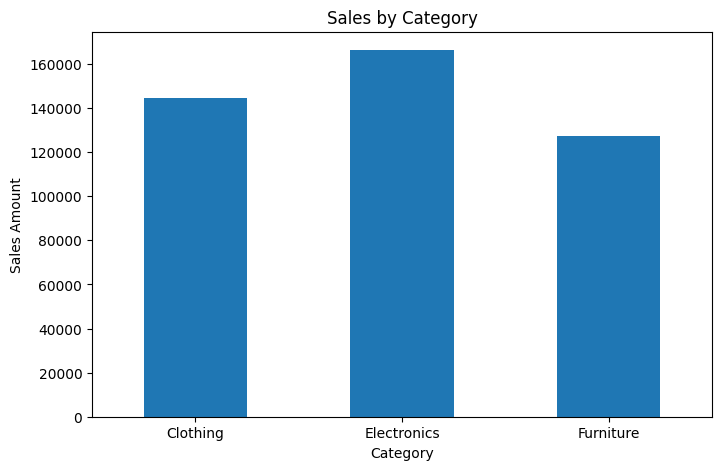

In [34]:
category_analysis["Amount"].plot(
    kind="bar",
    figsize=(8,5),
    title= "Sales by Category"
)

plt.xlabel("Category")
plt.ylabel("Sales Amount")
plt.xticks(rotation=0)
plt.show()

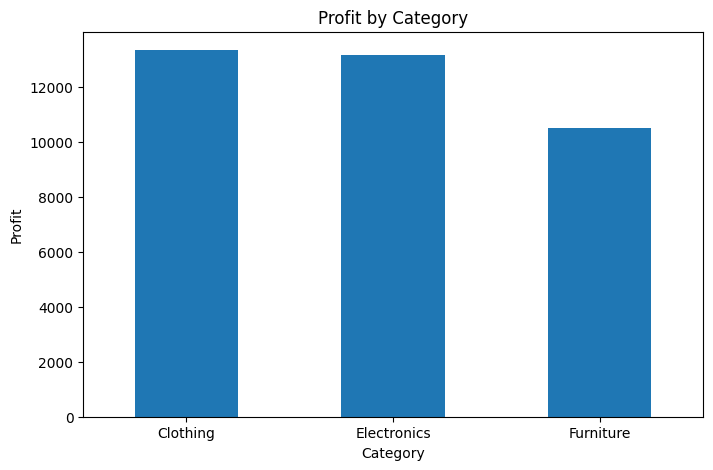

In [36]:
category_analysis["Profit"].plot(
    kind="bar",
    figsize=(8,5),
    title="Profit by Category"
)

plt.xlabel("Category")
plt.ylabel("Profit")
plt.xticks(rotation=0)
plt.show()

# Sub-Category Analysis

In [37]:
subcategory_analysis = df.groupby("Sub-Category")[["Amount","Profit","Quantity"]].sum()

In [40]:
subcategory_analysis.sort_values(
    by="Amount",
    ascending=False
)

,Amount,Profit,Quantity
Sub-Category,,,
Printers,59252,8606,291
Saree,59094,4057,795
Bookcases,56861,6516,297
Phones,46119,1847,304
Electronic Games,39168,-644,297
Chairs,34222,1627,277
Trousers,30039,2847,135
Tables,22614,3139,61
Accessories,21728,3353,262


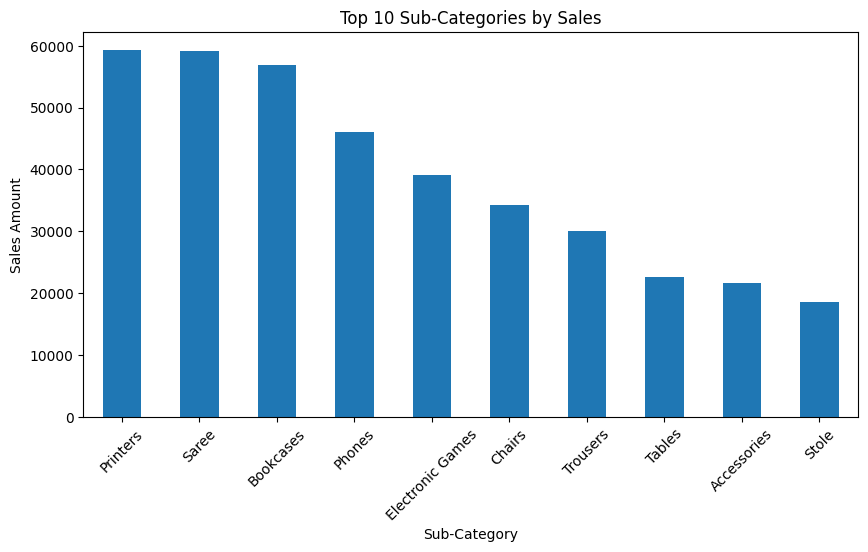

In [41]:
top_subcategories = subcategory_analysis.sort_values(
    by="Amount",
    ascending=False
).head(10)

top_subcategories["Amount"].plot(
    kind="bar",
    figsize=(10,5),
    title="Top 10 Sub-Categories by Sales"
    
)

plt.xlabel("Sub-Category")
plt.ylabel("Sales Amount")
plt.xticks(rotation = 45)
plt.show()


In [42]:
subcategory_analysis["Profit_Margin"] = (
    subcategory_analysis["Profit"] /
    subcategory_analysis["Amount"]
) * 100

In [43]:
subcategory_analysis.sort_values(
    by="Profit_Margin",
    ascending = False
)

,Amount,Profit,Quantity,Profit_Margin
Sub-Category,,,,
T-shirt,7382,1500,305,20.319697
Shirt,7555,1513,271,20.026473
Accessories,21728,3353,262,15.431701
Printers,59252,8606,291,14.524404
Tables,22614,3139,61,13.880782
Stole,18546,2431,671,13.107948
Hankerchief,14294,1823,741,12.753603
Bookcases,56861,6516,297,11.459524
Trousers,30039,2847,135,9.477679


# Profit Margin Visualization

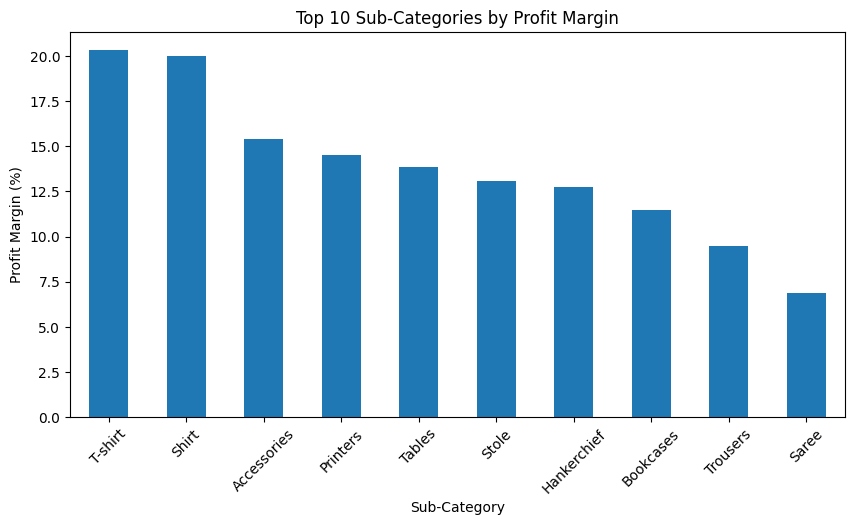

In [44]:
top_margin = subcategory_analysis.sort_values(
    by="Profit_Margin",
    ascending = False
).head(10)

top_margin["Profit_Margin"].plot(
    kind="bar",
    figsize=(10,5),
    title="Top 10 Sub-Categories by Profit Margin"
)

plt.xlabel("Sub-Category")
plt.ylabel("Profit Margin (%)")
plt.xticks(rotation = 45)
plt.show()

In [45]:
loss_making = subcategory_analysis[
    subcategory_analysis["Profit"] < 0
].sort_values(by="Profit")

loss_making

,Amount,Profit,Quantity,Profit_Margin
Sub-Category,,,,
Furnishings,13484,-806,310,-5.977455
Electronic Games,39168,-644,297,-1.644199
Kurti,3361,-401,164,-11.930973
Skirt,1946,-315,248,-16.187050
Leggings,2106,-130,186,-6.172840


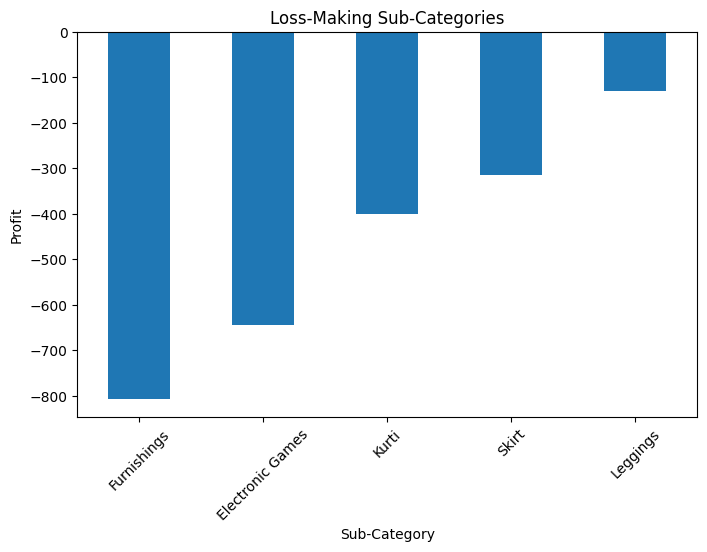

In [47]:
loss_making["Profit"].plot(
    kind="bar",
    figsize=(8,5),
    title="Loss-Making Sub-Categories"
)

plt.xlabel("Sub-Category")
plt.ylabel("Profit")
plt.xticks(rotation = 45)
plt.show()

# Monthly sales Analysis

In [48]:
df["Month"] = df["Order Date"].dt.month_name()

In [50]:
df["Month_Number"] = df["Order Date"].dt.month

In [53]:
monthly_sales = df.groupby(
    ["Month_Number","Month"]
)["Amount"].sum().sort_index()

monthly_sales

Month_Number  Month    
1             January      61632
2             February     38962
3             March        60694
4             April        34330
5             May          29093
6             June         23658
7             July         12966
8             August       31492
9             September    27283
10            October      31613
11            November     48469
12            December     37579
Name: Amount, dtype: int64

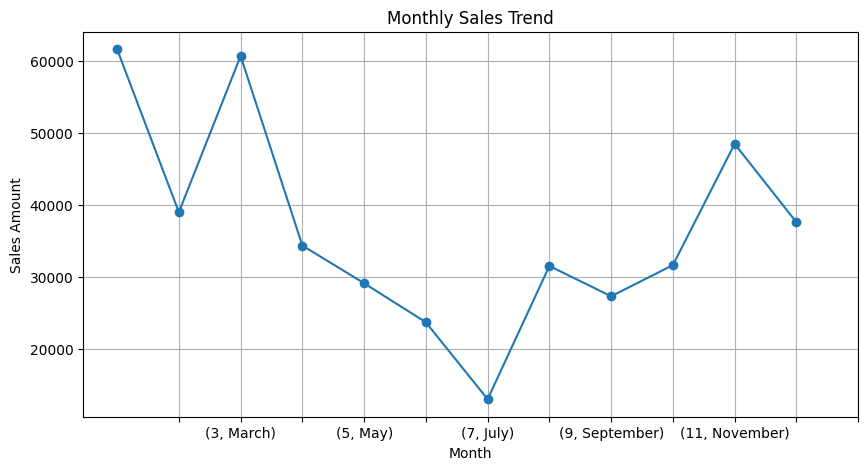

In [54]:
monthly_sales.plot(
    kind="line",
    figsize=(10,5),
    marker="o",
    title="Monthly Sales Trend"
)

plt.xlabel("Month")
plt.ylabel("Sales Amount")
plt.xticks(range(1,13))
plt.grid()
plt.show()

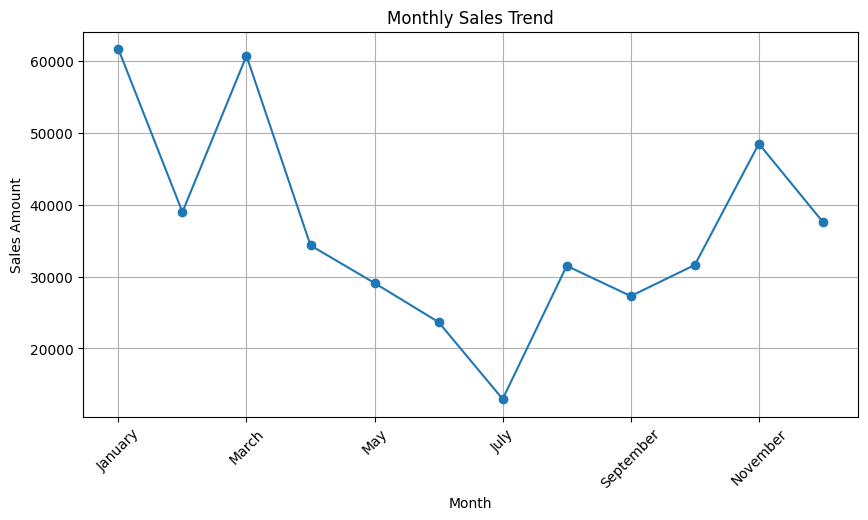

In [55]:
monthly_sales = df.groupby("Month_Number")["Amount"].sum()

months = [
    "January","February","March","April","May","June","July","August","September","October","November","December"
    
]

monthly_sales.index= months

monthly_sales.plot(
    kind="line",
    figsize=(10,5),
    marker="o",
    title="Monthly Sales Trend"
)

plt.xlabel("Month")
plt.ylabel("Sales Amount")
plt.xticks(rotation=45)
plt.grid()
plt.show()

In [56]:
monthly_profit = df.groupby("Month_Number")["Profit"].sum()

monthly_profit.index = months

monthly_profit

January       9684
February      8465
March         7793
April         4192
May          -3730
June           420
July         -2138
August        2068
September    -1399
October       2959
November     10253
December     -1604
Name: Profit, dtype: int64

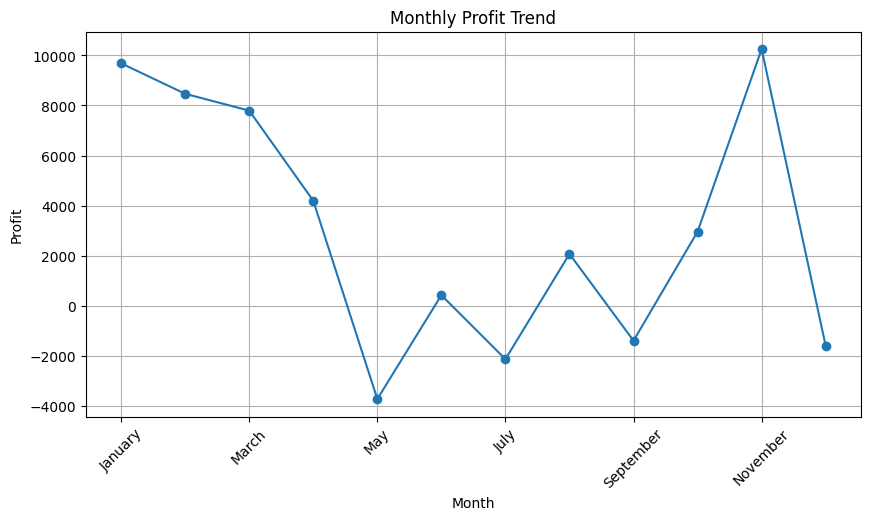

In [57]:
monthly_profit.plot(
    kind="line",
    figsize=(10,5),
    marker = "o",
    title = "Monthly Profit Trend"
)

plt.xlabel("Month")
plt.ylabel("Profit")
plt.xticks(rotation = 45)
plt.grid()
plt.show()

# Monthly Profit Margin

In [58]:
monthly_analysis = pd.DataFrame({
    "Sales": df.groupby("Month_Number")["Amount"].sum(),
    "Profit": df.groupby("Month_Number")["Profit"].sum()
})

monthly_analysis["Profit_Margin"] = (
    monthly_analysis["Profit"] / monthly_analysis["Sales"]
) * 100

monthly_analysis.index = months

monthly_analysis

,Sales,Profit,Profit_Margin
January,61632,9684,15.712617
February,38962,8465,21.726297
March,60694,7793,12.839819
April,34330,4192,12.210894
May,29093,-3730,-12.820953
June,23658,420,1.775298
July,12966,-2138,-16.489280
August,31492,2068,6.566747
September,27283,-1399,-5.127735
October,31613,2959,9.360073


# State- Wise Sales Analysis

In [59]:
state_analysis = df.groupby("State")[["Amount","Profit","Quantity"]].sum()

state_analysis = state_analysis.sort_values(by="Amount",ascending= False)

state_analysis

,Amount,Profit,Quantity
State,,,
Maharashtra,102498,6963,1091
Madhya Pradesh,87463,7382,1227
Uttar Pradesh,38362,3358,387
Delhi,22957,1958,290
Rajasthan,22334,-323,282
Gujarat,21371,3001,328
Punjab,16786,1571,216
West Bengal,14328,2074,216
Kerala,13871,2435,157


In [60]:
top_states = state_analysis.head(10)
top_states


,Amount,Profit,Quantity
State,,,
Maharashtra,102498,6963,1091
Madhya Pradesh,87463,7382,1227
Uttar Pradesh,38362,3358,387
Delhi,22957,1958,290
Rajasthan,22334,-323,282
Gujarat,21371,3001,328
Punjab,16786,1571,216
West Bengal,14328,2074,216
Kerala,13871,2435,157


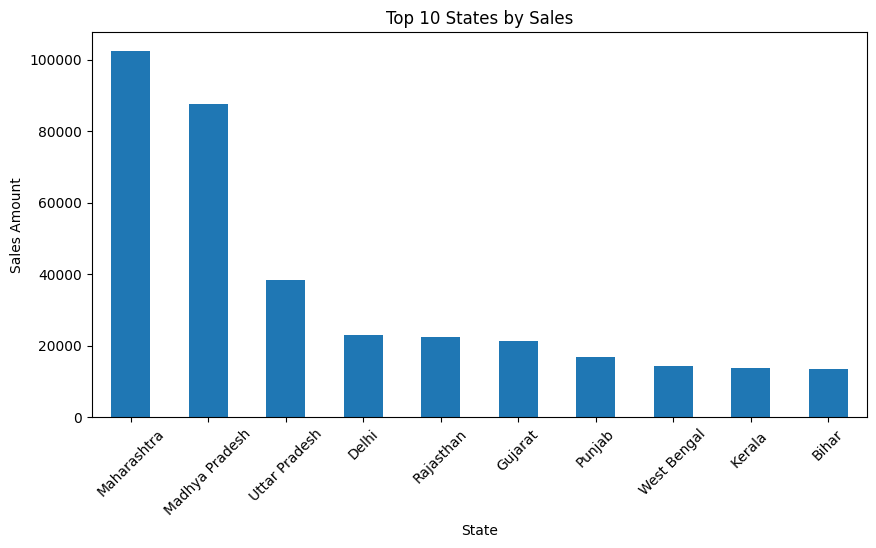

In [61]:
top_states["Amount"].plot(
    kind= "bar",
    figsize = (10,5),
    title = "Top 10 States by Sales"
)

plt.xlabel("State")
plt.ylabel("Sales Amount")
plt.xticks(rotation = 45)
plt.show()

In [62]:
state_analysis["Profit_Margin"] =(
    state_analysis["Profit"] / state_analysis["Amount"]
) * 100

state_analysis.sort_values(by="Profit_Margin",ascending = False)

,Amount,Profit,Quantity,Profit_Margin
State,,,,
Tamil Nadu,6276,2602,91,41.459528
Himachal Pradesh,8666,1662,113,19.178398
Kerala,13871,2435,157,17.554610
Haryana,8863,1325,111,14.949791
West Bengal,14328,2074,216,14.475154
Gujarat,21371,3001,328,14.042394
Bihar,13417,1787,206,13.318924
Punjab,16786,1571,216,9.358990
Uttar Pradesh,38362,3358,387,8.753454


In [63]:
loss_states = state_analysis[state_analysis["Profit"]<0]

loss_states

,Amount,Profit,Quantity,Profit_Margin
State,,,,
Rajasthan,22334,-323,282,-1.446225
Andhra Pradesh,13256,-280,146,-2.112251


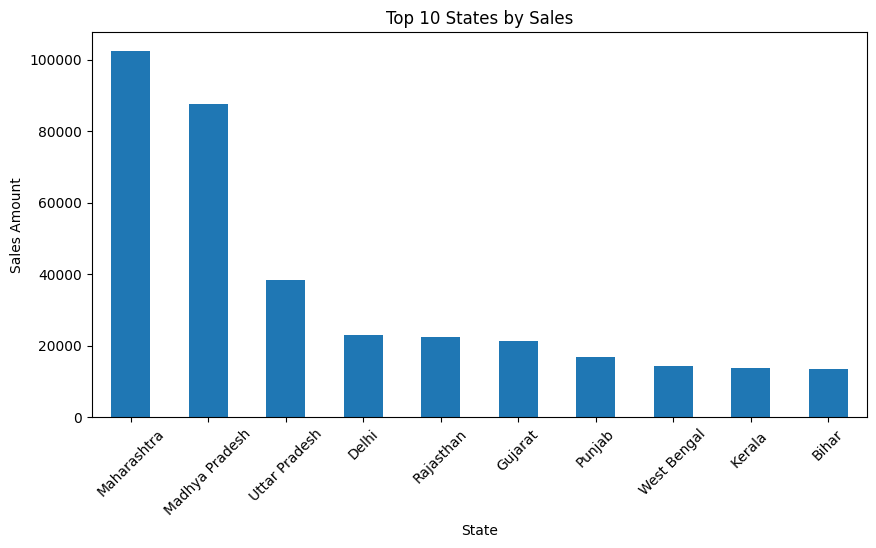

In [64]:
top_states = state_analysis.sort_values(
    by = "Amount",
    ascending = False
).head(10)

top_states["Amount"].plot(
    kind = "bar",
    figsize = (10,5),
    title = "Top 10 States by Sales"
)
plt.xlabel("State")
plt.ylabel("Sales Amount")
plt.xticks(rotation = 45)
plt.show()

In [65]:
customer_analysis = df.groupby("CustomerName") [["Amount","Profit","Quantity"]].sum()

customer_analysis = customer_analysis.sort_values(by = "Amount",ascending = False)

customer_analysis.head(10)

,Amount,Profit,Quantity
CustomerName,,,
Harivansh,9902,-157,57
Madhav,9365,1848,53
Madan Mohan,7766,2166,54
Shiva,6339,669,46
Vishakha,6120,-173,59
Vrinda,5820,917,54
Lalita,5809,400,23
Priyanka,5762,1276,79
Shruti,5750,485,67


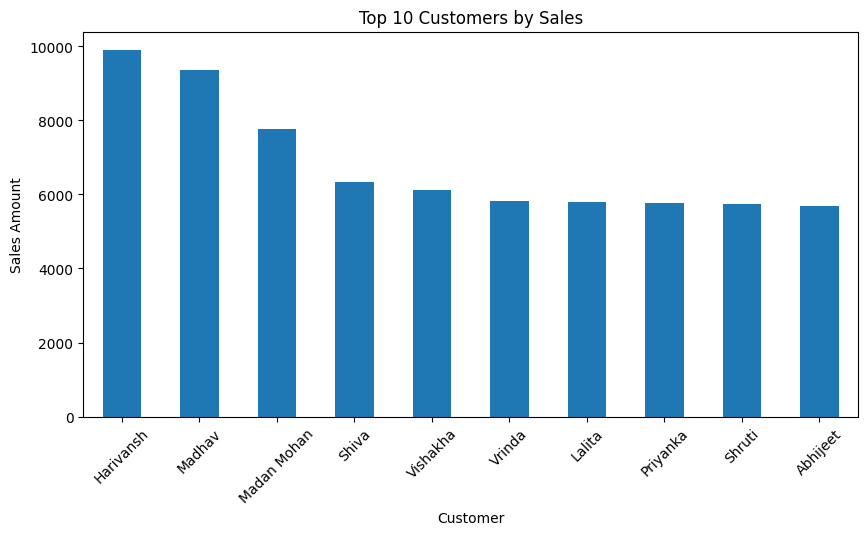

In [66]:
top_customer = customer_analysis.head(10)

top_customer["Amount"].plot(
    kind = "bar",
    figsize = (10,5),
    title = "Top 10 Customers by Sales"
)
plt.xlabel("Customer")
plt.ylabel("Sales Amount")
plt.xticks(rotation = 45)
plt.show()

In [67]:
customer_analysis.sort_values(by="Profit",ascending = False).head(10)

,Amount,Profit,Quantity
CustomerName,,,
Madan Mohan,7766,2166,54
Aarushi,4701,2059,49
Shrichand,3828,1901,20
Madhav,9365,1848,53
Priyanka,5762,1276,79
Sarita,5449,1183,50
Bhishm,4907,1165,26
Bharat,1579,1143,25
Abhijeet,5691,1078,45


In [69]:
top_profit_customers = customer_analysis.sort_values(
    by="Profit",
    ascending = False
).head(10)

top_profit_customers

,Amount,Profit,Quantity
CustomerName,,,
Madan Mohan,7766,2166,54
Aarushi,4701,2059,49
Shrichand,3828,1901,20
Madhav,9365,1848,53
Priyanka,5762,1276,79
Sarita,5449,1183,50
Bhishm,4907,1165,26
Bharat,1579,1143,25
Abhijeet,5691,1078,45


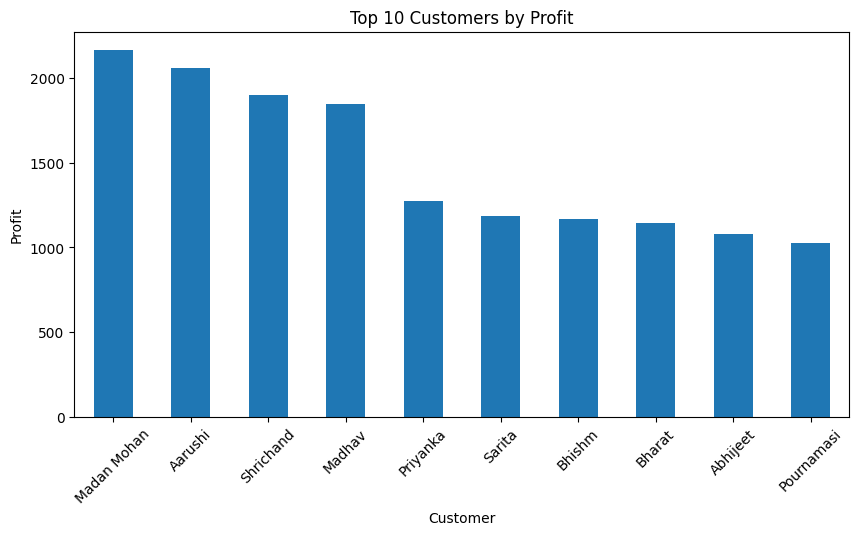

In [70]:
top_profit_customers["Profit"].plot(
    kind = "bar",
    figsize = (10,5),
    title = "Top 10 Customers by Profit"
)
plt.xlabel("Customer")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.show()

In [72]:
payment_analysis = df.groupby("PaymentMode")[["Amount","Profit","Quantity"]].sum()
payment_analysis

,Amount,Profit,Quantity
PaymentMode,,,
COD,155181,12547,2456
Credit Card,86932,12612,672
Debit Card,49136,3694,741
EMI,77881,4824,589
UPI,68641,3286,1157


In [73]:
df["PaymentMode"].value_counts()

PaymentMode
COD            684
UPI            331
Debit Card     202
Credit Card    163
EMI            120
Name: count, dtype: int64

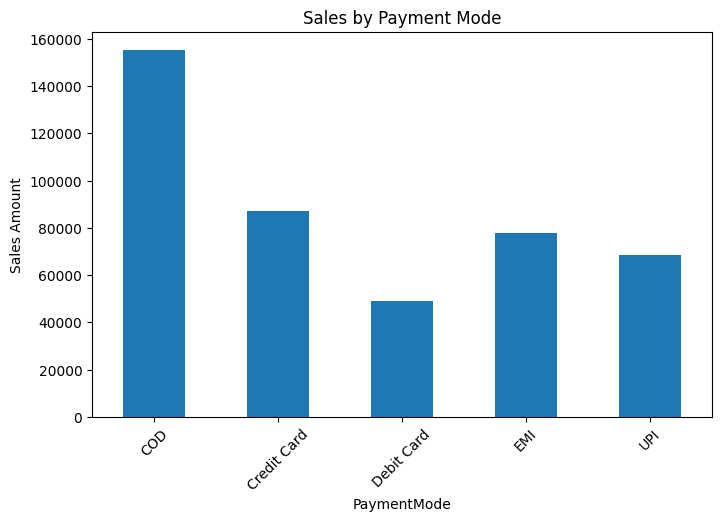

In [74]:
payment_analysis["Amount"].plot(
    kind = "bar",
    figsize = (8,5),
    title = "Sales by Payment Mode"

)
plt.xlabel("PaymentMode")
plt.ylabel("Sales Amount")
plt.xticks(rotation = 45)
plt.show()

In [77]:
city_analysis = df.groupby("City")[["Amount","Profit","Quantity"]].sum()

city_analysis = city_analysis.sort_values(
    by= "Amount",
    ascending = False
)
city_analysis.head(10)

,Amount,Profit,Quantity
City,,,
Indore,63680,6763,980
Mumbai,58886,803,699
Pune,43612,6160,392
Mathura,28747,3335,194
Bhopal,23783,619,247
Delhi,22957,1958,290
Chandigarh,21142,2778,275
Ahmedabad,14543,1846,235
Kolkata,14328,2074,216


In [78]:
city_analysis["Profit_Margin"] = (
    city_analysis["Profit"] / city_analysis["Amount"]
) * 100

city_analysis.sort_values(
    by="Profit",
    ascending= False
).head(10)

,Amount,Profit,Quantity,Profit_Margin
City,,,,
Indore,63680,6763,980,10.620289
Pune,43612,6160,392,14.124553
Mathura,28747,3335,194,11.601211
Chandigarh,21142,2778,275,13.139722
Chennai,6276,2602,91,41.459528
Thiruvananthapuram,13871,2435,157,17.554610
Kolkata,14328,2074,216,14.475154
Delhi,22957,1958,290,8.528989
Ahmedabad,14543,1846,235,12.693392


In [79]:
city_analysis["Profit_Margin"] = (
    city_analysis["Profit"] / city_analysis["Amount"]
) * 100

city_analysis.sort_values(
    by = "Profit_Margin",
    ascending=False
).head(10)

,Amount,Profit,Quantity,Profit_Margin
City,,,,
Chennai,6276,2602,91,41.459528
Simla,8666,1662,113,19.178398
Thiruvananthapuram,13871,2435,157,17.554610
Surat,6828,1155,93,16.915641
Kolkata,14328,2074,216,14.475154
Pune,43612,6160,392,14.124553
Patna,13417,1787,206,13.318924
Chandigarh,21142,2778,275,13.139722
Ahmedabad,14543,1846,235,12.693392


In [80]:
total_sales = df["Amount"].sum()
total_profit = df["Profit"].sum()
total_quantity  = df["Quantity"].sum()
total_orders = df["Order ID"].nunique()

overall_margin = (total_profit / total_sales) * 100

print("Total Sales:", total_sales)
print("Total Profit:", total_profit)
print("Total Quantity:", total_quantity)
print("Total Orders:", total_orders)
print("Overall Profit Margin:", overall_margin)





Total Sales: 437771
Total Profit: 36963
Total Quantity: 5615
Total Orders: 500
Overall Profit Margin: 8.443455596647562


In [81]:
import os

os.makedirs("charts",exist_ok=True)
print("Charts folder ready!")

Charts folder ready!


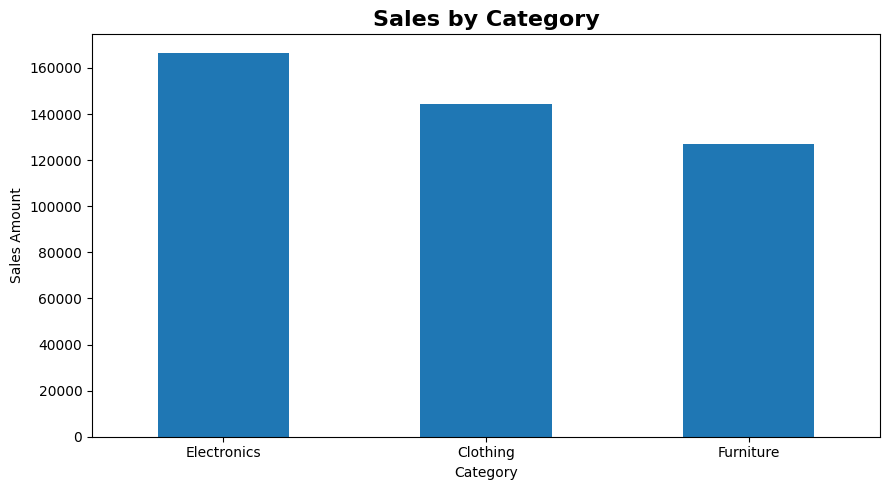

In [83]:
# 1. Sales by category

plt.figure(figsize=(9,5))

category_analysis["Amount"].sort_values(ascending=False).plot(
    kind="bar"
)
plt.title("Sales by Category", fontsize=16 , fontweight="bold")
plt.xlabel("Category")
plt.ylabel("Sales Amount")
plt.xticks(rotation = 0)
plt.tight_layout()

plt.savefig(
    "charts/01_sales_by_category.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

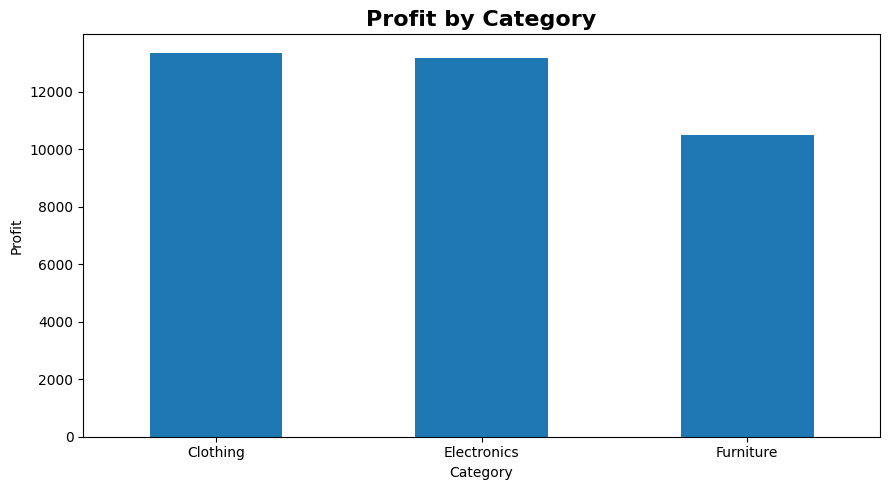

In [84]:
# 2. Profit by Category

plt.figure(figsize=(9,5))

category_analysis["Profit"].sort_values(ascending=False).plot(
    kind="bar"
)

plt.title("Profit by Category",fontsize=16,fontweight="bold")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    "charts/02_profit_by_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

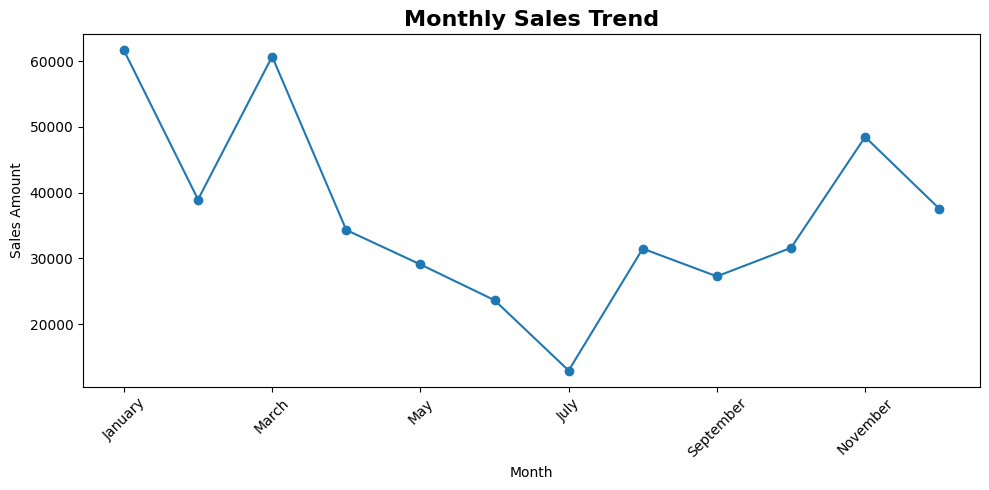

In [85]:
# 3. Monthly Sales Trend

plt.figure(figsize=(10,5))

monthly_sales.plot(
    kind="line",
    marker="o"
)

plt.title("Monthly Sales Trend",fontsize=16,fontweight="bold")

plt.xlabel("Month")
plt.ylabel("Sales Amount")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("charts/03_monthly_sales_trend.png",
           dpi=300,
           bbox_inches="tight")

plt.show()

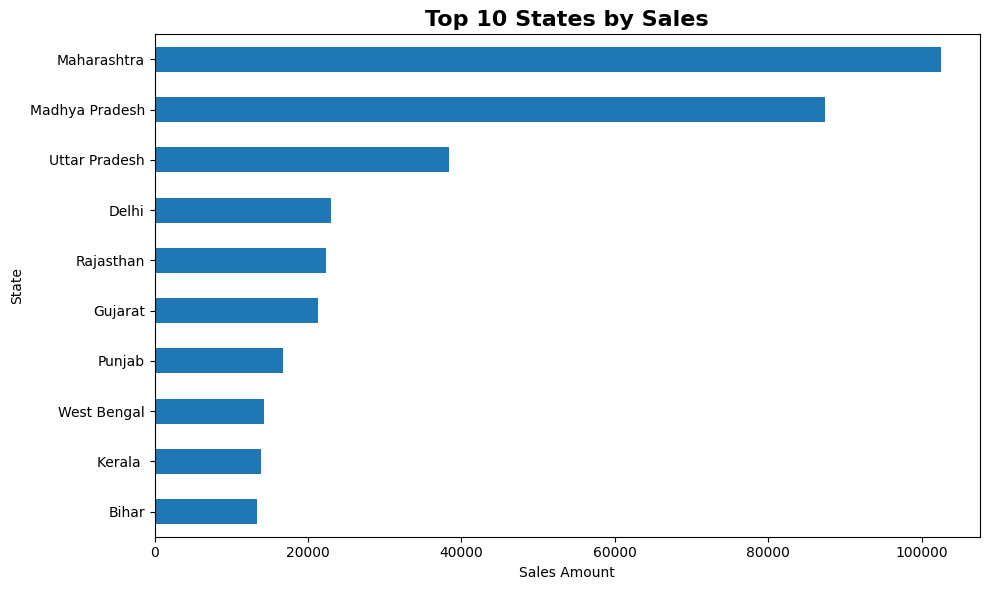

In [90]:
# 4. Top 10 States by Sales
top_states = state_analysis.sort_values(
     by="Amount",
     ascending = False
).head(10)

plt.figure(figsize=(10,6))

top_states["Amount"].sort_values().plot(
    kind="barh",
)

plt.title("Top 10 States by Sales",
         fontsize=16,
         fontweight="bold")
plt.xlabel("Sales Amount")
plt.ylabel("State")
plt.tight_layout()

plt.savefig("charts/04_top_states_sales.png",
            dpi=300,
            bbox_inches="tight"
)
plt.show()

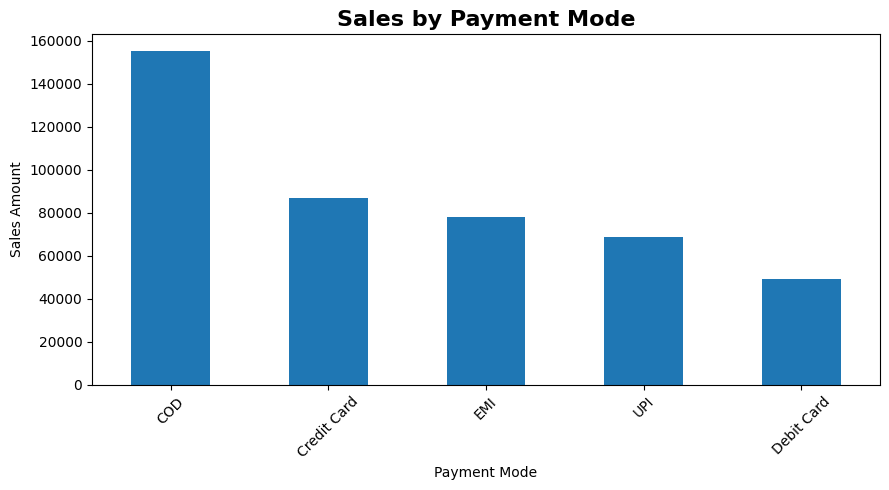

In [92]:
# 5. Sales by Payment Mode

plt.figure(figsize=(9,5))

payment_analysis["Amount"].sort_values(
    ascending=False
).plot(kind="bar")

plt.title("Sales by Payment Mode",
         fontsize=16,
         fontweight="bold")

plt.xlabel("Payment Mode")
plt.ylabel("Sales Amount")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("charts/05_sales_by_payment_mode.png",
           dpi=300,
           bbox_inches="tight")

plt.show()
